In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
infile = '/g/data/xv83/dbi599/rba/Rx5day/ACCESS-CM2/ssp585/rx5day_yr_ACCESS-CM2_ssp585_ensemble_aus-states-cities_1850-2100.csv'

In [5]:
df = pd.read_csv(infile)

In [6]:
df

,year,model,run,experiment,NSW,VIC,QLD,SA,WA,TAS,NT,AUS,Melbourne,Sydney,Brisbane,Darwin,Perth,Adelaide,Hobart
0,1850,ACCESS-CM2,r10i1p1f1,historical,71.89,66.50,140.00,78.92,128.86,50.37,138.95,118.28,56.56,150.09,168.12,230.12,84.68,74.46,41.70
1,1850,ACCESS-CM2,r1i1p1f1,historical,67.80,96.99,80.91,96.79,126.65,53.86,144.83,108.09,50.11,66.27,127.69,272.21,131.06,57.17,70.15
2,1850,ACCESS-CM2,r2i1p1f1,historical,69.92,71.67,111.71,44.04,58.15,70.39,142.09,84.87,49.86,81.90,41.90,148.71,104.38,53.20,45.90
3,1850,ACCESS-CM2,r3i1p1f1,historical,80.70,45.68,62.74,49.89,129.29,58.15,105.68,91.85,35.80,237.56,105.03,396.61,68.28,48.55,59.52
4,1850,ACCESS-CM2,r4i1p1f1,historical,79.34,73.49,131.85,61.42,82.43,76.19,111.46,95.31,48.15,90.63,115.10,246.92,91.31,35.11,71.46
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2505,2100,ACCESS-CM2,r5i1p1f1,ssp585,159.43,109.18,159.40,80.27,82.86,72.25,223.04,133.04,142.83,283.66,37.76,368.22,146.72,32.83,47.37
2506,2100,ACCESS-CM2,r6i1p1f1,ssp585,131.66,77.60,228.83,47.25,76.07,100.52,129.01,122.09,61.29,97.74,85.87,321.12,37.45,45.27,53.92
2507,2100,ACCESS-CM2,r7i1p1f1,ssp585,165.32,53.61,193.31,77.64,69.03,73.63,196.67,130.15,46.23,172.71,149.87,1429.46,25.44,16.63,51.70
2508,2100,ACCESS-CM2,r8i1p1f1,ssp585,135.82,85.41,105.25,97.74,72.92,97.72,289.39,128.56,162.93,432.66,69.27,818.46,45.73,83.48,86.21


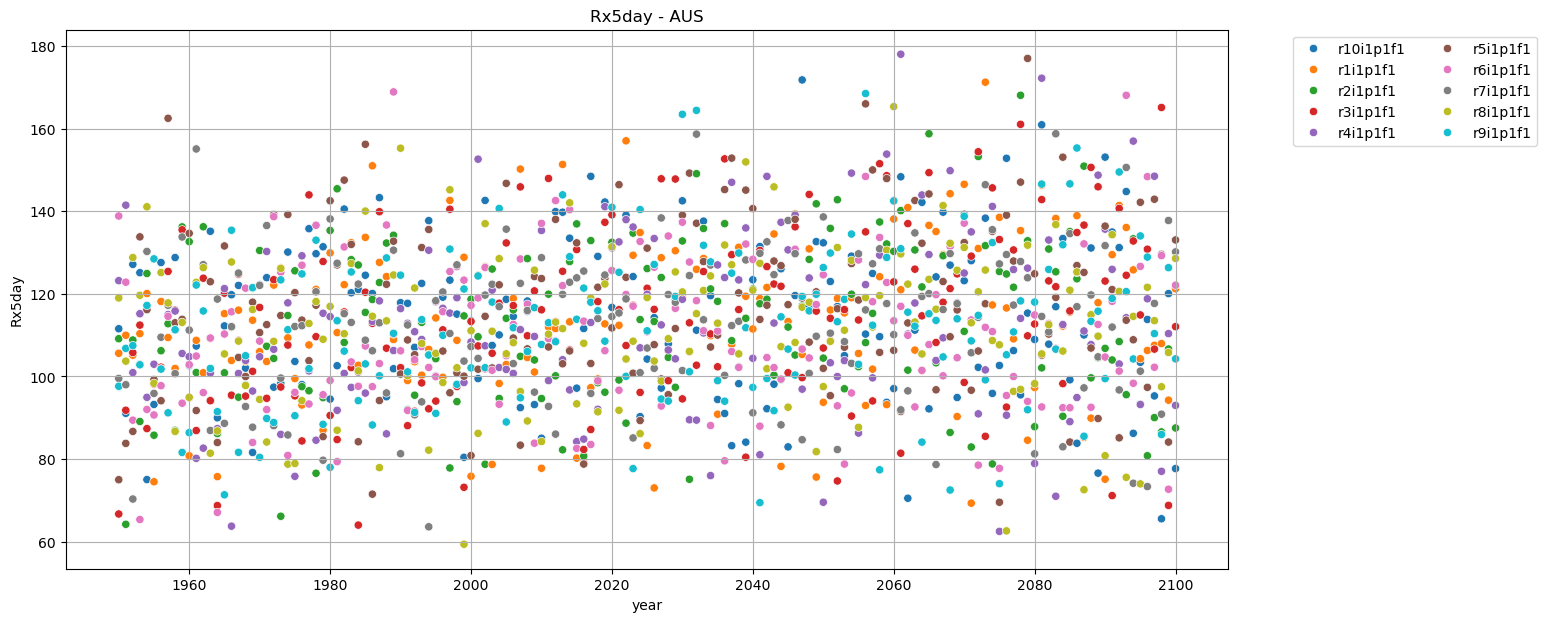

In [40]:
fig, ax = plt.subplots(figsize=[15,7])
sns.scatterplot(
    ax=ax,
    data=df[df['year'] >= 1950],
    x='year',
    y='AUS',
    hue='run',
)
ax.set_ylabel('Rx5day')
ax.set_title('Rx5day - AUS')
ax.legend(bbox_to_anchor=(1.05, 1.0), ncol=2)
ax.grid()
plt.show()

In [9]:
def prep_data(df):
    """Prepare data for percentile and likelihood calculations."""

    ref_start = 1950
    ref_end = 2014

    df = df.drop(['model', 'experiment'], axis=1) 
    df_ref = df[(df['year'] >= ref_start) & (df['year'] <= ref_end)]
    df_data = df.drop(['year', 'run'], axis=1)
    df_ref_data = df_ref.drop(['year', 'run'], axis=1)

    return df_data, df_ref_data

In [10]:
df_data, df_ref_data = prep_data(df)

In [13]:
df_data

,NSW,VIC,QLD,SA,WA,TAS,NT,AUS,Melbourne,Sydney,Brisbane,Darwin,Perth,Adelaide,Hobart
0,71.89,66.50,140.00,78.92,128.86,50.37,138.95,118.28,56.56,150.09,168.12,230.12,84.68,74.46,41.70
1,67.80,96.99,80.91,96.79,126.65,53.86,144.83,108.09,50.11,66.27,127.69,272.21,131.06,57.17,70.15
2,69.92,71.67,111.71,44.04,58.15,70.39,142.09,84.87,49.86,81.90,41.90,148.71,104.38,53.20,45.90
3,80.70,45.68,62.74,49.89,129.29,58.15,105.68,91.85,35.80,237.56,105.03,396.61,68.28,48.55,59.52
4,79.34,73.49,131.85,61.42,82.43,76.19,111.46,95.31,48.15,90.63,115.10,246.92,91.31,35.11,71.46
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2505,159.43,109.18,159.40,80.27,82.86,72.25,223.04,133.04,142.83,283.66,37.76,368.22,146.72,32.83,47.37
2506,131.66,77.60,228.83,47.25,76.07,100.52,129.01,122.09,61.29,97.74,85.87,321.12,37.45,45.27,53.92
2507,165.32,53.61,193.31,77.64,69.03,73.63,196.67,130.15,46.23,172.71,149.87,1429.46,25.44,16.63,51.70
2508,135.82,85.41,105.25,97.74,72.92,97.72,289.39,128.56,162.93,432.66,69.27,818.46,45.73,83.48,86.21


In [12]:
df_ref_data

,NSW,VIC,QLD,SA,WA,TAS,NT,AUS,Melbourne,Sydney,Brisbane,Darwin,Perth,Adelaide,Hobart
1000,100.77,78.61,159.13,43.94,91.75,90.98,149.95,111.55,63.54,118.92,216.38,387.13,109.66,40.90,74.16
1001,73.35,66.20,123.14,68.07,86.47,56.13,174.57,105.61,51.99,60.11,182.43,304.37,74.90,45.68,49.91
1002,123.94,61.86,211.79,63.54,55.91,59.62,112.22,109.14,40.22,151.73,185.56,358.96,73.87,38.54,66.42
1003,101.63,50.28,71.42,36.29,77.65,48.66,45.34,66.71,65.51,207.90,158.02,300.86,56.91,35.92,42.31
1004,96.36,57.79,229.40,67.14,96.09,73.17,108.15,123.19,43.36,64.11,36.27,367.37,56.69,54.87,50.74
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1645,106.33,73.23,160.97,37.68,68.11,64.40,164.77,106.18,47.98,89.10,145.80,383.17,56.05,43.84,48.97
1646,114.61,103.11,191.24,91.35,117.75,73.26,178.26,140.38,57.78,215.05,231.72,237.65,62.49,34.46,40.58
1647,162.16,105.92,180.00,63.07,102.29,78.90,113.23,122.81,67.84,183.51,160.44,253.80,55.54,58.94,82.96
1648,119.69,43.26,236.03,40.29,90.01,47.58,227.69,142.03,42.34,107.88,169.33,403.36,65.30,24.31,44.40


In [14]:
nruns = len(df['run'].unique())
window = nruns * 20

In [16]:
window

200

In [74]:
def yrs_to_quantile(yr, decimal_places=5):
    """Convert a 1-in-X year return period to a quantile."""

    quantile = 1 - (1 / yr)
    
    return np.round(quantile, decimal_places)


def quantile_to_yrs(quantile):
    """Convert a quantile to a 1-in-X year return period."""

    yrs = 1 / (1 - quantile)
    
    return int(np.round(yrs, 0))

In [21]:
quantiles = [float(yrs_to_quantile(yr)) for yr in np.arange(10, 101, 2)]
decimal_places = 3

In [23]:
thresholds = df_ref_data.quantile(quantiles)

In [24]:
thresholds

,NSW,VIC,QLD,SA,WA,TAS,NT,AUS,Melbourne,Sydney,Brisbane,Darwin,Perth,Adelaide,Hobart
0.90000,133.178000,100.600000,179.937000,104.129000,125.028000,81.935000,196.940000,132.324000,103.238000,201.204000,230.099000,503.576000,108.506000,90.338000,79.921000
0.91667,135.704578,103.058051,182.786201,107.095064,126.989707,83.181071,203.995097,135.099415,107.803214,211.636135,243.745649,522.209119,111.585843,94.848084,81.965356
0.92857,136.949740,105.884193,185.373191,111.383933,128.773321,84.568869,205.777032,136.046030,114.250353,220.299667,255.728702,544.729407,113.700612,100.508869,83.391967
0.93750,138.092500,107.390000,187.505000,114.381250,130.850625,86.463125,208.158125,137.020625,117.851875,224.708750,262.766875,568.813750,115.704375,107.066250,84.194375
0.94444,139.876820,108.437662,188.428247,116.755974,132.232403,88.339807,209.986820,138.647858,122.362212,230.881821,276.697737,576.586561,118.197143,110.948247,85.344286
0.95000,142.482000,110.615500,190.925000,119.114000,134.162000,88.863000,212.296000,139.508000,127.308000,236.722500,283.068000,586.661000,120.046000,111.930500,86.638000
0.95455,144.128393,113.835915,192.766741,120.122419,135.555030,90.885561,216.611416,139.965384,134.197080,240.680531,285.273009,604.676091,120.790472,114.888437,87.805148
0.95833,146.776966,114.795813,193.936494,121.768166,135.961234,91.686851,217.581949,140.475617,138.061983,242.714140,289.480101,616.372178,123.235536,117.958119,90.980749
0.96154,147.772617,115.845763,195.969470,122.633946,136.290654,92.770395,218.320000,140.685784,140.335784,247.981173,292.956947,637.201526,126.848276,119.635379,92.632627
0.96429,149.774326,118.143315,196.884094,123.183315,136.813747,93.398157,218.740347,141.391442,141.008473,250.709862,300.162639,641.681242,128.299252,121.234526,93.047147


In [41]:
#for quantile in quantiles:
quantile = 0.9
df_threshold_test = df_data > thresholds.loc[quantile]
odds = df_threshold_test.rolling(window, step=nruns, center=True).apply(lambda s: (sum(s) / window) * 100)
odds.index = df['year'].unique()
odds = odds.dropna()
odds.index.name = 'year'

In [90]:
thresholds.loc[0.9]

NSW          133.178
VIC          100.600
QLD          179.937
SA           104.129
WA           125.028
TAS           81.935
NT           196.940
AUS          132.324
Melbourne    103.238
Sydney       201.204
Brisbane     230.099
Darwin       503.576
Perth        108.506
Adelaide      90.338
Hobart        79.921
Name: 0.9, dtype: float64

Probability (%) of exceeding the threshold calculated empirically across all model runs for a 20-year rolling window centered on each year

In [43]:
odds

,NSW,VIC,QLD,SA,WA,TAS,NT,AUS,Melbourne,Sydney,Brisbane,Darwin,Perth,Adelaide,Hobart
year,,,,,,,,,,,,,,,
1860,6.5,8.5,6.5,7.5,8.5,11.5,8.0,8.0,7.0,10.5,7.5,6.0,9.5,7.0,8.0
1861,6.5,8.5,6.5,7.0,8.0,11.0,9.0,8.0,7.0,10.0,8.5,6.0,9.0,7.0,7.5
1862,6.0,8.0,6.5,7.0,9.0,12.0,9.5,7.5,6.5,9.5,9.0,6.0,10.0,6.5,8.0
1863,5.5,7.5,5.5,6.5,9.0,12.5,9.0,6.5,5.5,10.0,9.0,6.0,10.0,6.5,8.0
1864,5.5,8.0,5.0,7.0,9.0,12.5,9.0,6.0,5.5,10.0,9.0,6.5,9.0,8.0,8.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2087,26.5,22.0,19.5,11.0,11.0,25.0,23.0,23.0,23.0,14.5,16.0,31.0,4.0,8.5,17.5
2088,28.0,22.0,19.5,10.5,11.0,26.0,24.5,24.0,23.0,16.5,15.5,32.0,3.5,8.5,18.5
2089,27.5,21.0,19.0,10.0,9.5,24.0,24.5,22.5,23.0,16.0,14.5,32.0,4.0,10.5,18.0


In [52]:
last_window = np.sort(df_data['AUS'][-200:].values)[::-1]
last_window

array([172.2 , 168.06, 165.11, 160.92, 158.75, 156.97, 155.3 , 153.09,
       153.08, 150.91, 150.61, 150.59, 149.49, 148.73, 148.47, 148.37,
       146.62, 146.57, 146.3 , 145.91, 144.76, 142.9 , 142.81, 142.16,
       141.38, 140.67, 138.92, 138.25, 137.75, 136.76, 136.64, 136.39,
       136.06, 135.66, 135.07, 134.96, 134.85, 134.58, 134.31, 134.02,
       133.39, 133.32, 133.04, 133.03, 132.79, 132.09, 131.88, 131.67,
       131.19, 131.1 , 130.85, 130.8 , 130.15, 129.56, 129.48, 129.25,
       128.9 , 128.56, 126.86, 126.64, 126.34, 125.93, 125.91, 125.8 ,
       125.33, 125.31, 125.19, 125.18, 124.49, 123.64, 123.13, 123.09,
       122.09, 121.72, 121.58, 121.22, 121.04, 120.88, 120.59, 120.54,
       120.06, 119.73, 119.13, 118.87, 118.8 , 118.19, 117.86, 117.68,
       116.89, 116.89, 115.86, 115.8 , 115.57, 114.95, 114.89, 114.55,
       114.53, 114.22, 113.8 , 113.62, 113.51, 113.35, 112.83, 112.59,
       112.56, 112.53, 112.44, 112.2 , 112.06, 111.95, 111.01, 110.8 ,
      

In [58]:
len(last_window)

200

In [86]:
decimal_places = 3
for quantile in quantiles[::-1]:
    threshold = thresholds['AUS'].loc[quantile]
    tlabel = np.round(threshold, 2)
    exceedences = np.sum(last_window > threshold)
    percentile = round(quantile * 100, decimal_places)
    plabel = str(percentile).ljust(decimal_places+3, "0")
    rp = quantile_to_yrs(quantile)
    print(f'{plabel} percentile', f'or 1-in-{rp} yr event:', f'{exceedences} values exceed the threshold of {tlabel}mm')

99.000 percentile or 1-in-100 yr event: 9 values exceed the threshold of 151.16mm
98.980 percentile or 1-in-98 yr event: 9 values exceed the threshold of 151.12mm
98.958 percentile or 1-in-96 yr event: 9 values exceed the threshold of 151.08mm
98.936 percentile or 1-in-94 yr event: 9 values exceed the threshold of 151.03mm
98.913 percentile or 1-in-92 yr event: 9 values exceed the threshold of 150.96mm
98.889 percentile or 1-in-90 yr event: 10 values exceed the threshold of 150.83mm
98.864 percentile or 1-in-88 yr event: 10 values exceed the threshold of 150.7mm
98.837 percentile or 1-in-86 yr event: 12 values exceed the threshold of 150.56mm
98.810 percentile or 1-in-84 yr event: 12 values exceed the threshold of 150.42mm
98.780 percentile or 1-in-82 yr event: 12 values exceed the threshold of 150.27mm
98.750 percentile or 1-in-80 yr event: 12 values exceed the threshold of 149.94mm
98.718 percentile or 1-in-78 yr event: 13 values exceed the threshold of 149.47mm
98.684 percentile or 